In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import joblib

In [ ]:
df = pd.read_csv('/content/train.csv')

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
label = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = label.fit_transform(df[col])


In [ ]:
stats = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Mode": df.mode().iloc[0],
    "Variance": df.var(),
    "Standard Deviation": df.std()
})

print(stats)


                   Mean    Median    Mode      Variance  Standard Deviation
PassengerId  446.000000  446.0000    1.00  66231.000000          257.353842
Survived       0.383838    0.0000    0.00      0.236772            0.486592
Pclass         2.308642    3.0000    3.00      0.699015            0.836071
Name         445.000000  445.0000    0.00  66231.000000          257.353842
Sex            0.647587    1.0000    1.00      0.228475            0.477990
Age           29.699118   28.0000   24.00    211.019125           14.526497
SibSp          0.523008    0.0000    0.00      1.216043            1.102743
Parch          0.381594    0.0000    0.00      0.649728            0.806057
Ticket       338.528620  337.0000   80.00  40340.986540          200.850657
Fare          32.204208   14.4542    8.05   2469.436846           49.693429
Cabin        130.744108  147.0000  147.00   1297.745682           36.024237
Embarked       1.538721    2.0000    2.00      0.630802            0.794231


In [ ]:
print(df.skew())

PassengerId    0.000000
Survived       0.478523
Pclass        -0.630548
Name           0.000000
Sex           -0.618921
Age            0.389108
SibSp          3.695352
Parch          2.749117
Ticket         0.000246
Fare           4.787317
Cabin         -2.167313
Embarked      -1.246689
dtype: float64


In [ ]:
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, ":", len(outliers), "Outliers")

PassengerId : 0 Outliers
Survived : 0 Outliers
Pclass : 0 Outliers
Name : 0 Outliers
Sex : 0 Outliers
Age : 11 Outliers
SibSp : 46 Outliers
Parch : 213 Outliers
Ticket : 0 Outliers
Fare : 116 Outliers
Cabin : 204 Outliers
Embarked : 0 Outliers


In [ ]:
corr = df.corr()
print("\nCorrelation Matrix")
print(corr)


Correlation Matrix
             PassengerId  Survived    Pclass      Name       Sex       Age  \
PassengerId     1.000000 -0.005007 -0.035144 -0.038559  0.042939  0.036847   
Survived       -0.005007  1.000000 -0.338481 -0.057343 -0.543351 -0.077221   
Pclass         -0.035144 -0.338481  1.000000  0.052831  0.131900 -0.369226   
Name           -0.038559 -0.057343  0.052831  1.000000  0.020314  0.062583   
Sex             0.042939 -0.543351  0.131900  0.020314  1.000000  0.093254   
Age             0.036847 -0.077221 -0.369226  0.062583  0.093254  1.000000   
SibSp          -0.057527 -0.035322  0.083081 -0.017230 -0.114631 -0.308247   
Parch          -0.001652  0.081629  0.018443 -0.049105 -0.245489 -0.189119   
Ticket         -0.056554 -0.164549  0.319869  0.047348  0.059372 -0.075934   
Fare            0.012658  0.257307 -0.549500 -0.049173 -0.182333  0.096067   
Cabin          -0.035077 -0.254888  0.684121  0.061959  0.096681 -0.252331   
Embarked        0.013083 -0.163517  0.157112

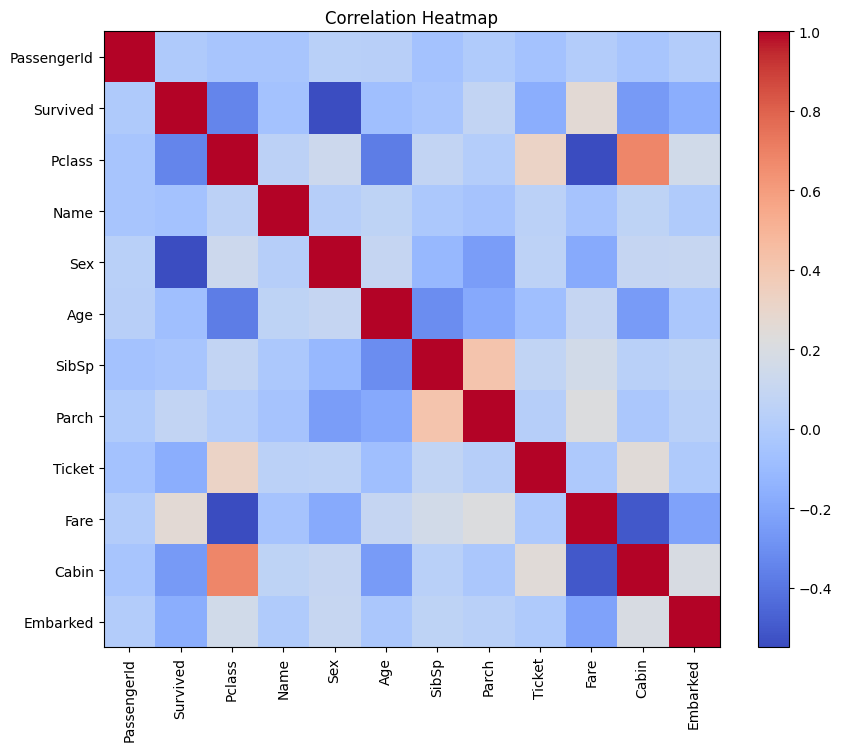

In [ ]:
plt.figure(figsize=(10,8))
plt.imshow(corr, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
target = 'Survived'

correlation = corr[target].abs().sort_values(ascending=False)

In [ ]:
print("\nTop Correlated Features")
print(correlation)


Top Correlated Features
Survived       1.000000
Sex            0.543351
Pclass         0.338481
Fare           0.257307
Cabin          0.254888
Ticket         0.164549
Embarked       0.163517
Parch          0.081629
Age            0.077221
Name           0.057343
SibSp          0.035322
PassengerId    0.005007
Name: Survived, dtype: float64


In [ ]:
top_features = correlation.index[1:6]


In [ ]:
print("\nSelected Features")
print(top_features)


Selected Features
Index(['Sex', 'Pclass', 'Fare', 'Cabin', 'Ticket'], dtype='object')


In [ ]:
X_simple = df[[top_features[0]]]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42)
simple_model = LinearRegression()
simple_model.fit(X_train, y_train)
simple_pred = simple_model.predict(X_test)


In [ ]:
X = df[top_features]
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X, y, test_size=0.2, random_state=42)
multiple_model = LinearRegression()
multiple_model.fit(X_train2, y_train2)
multiple_pred = multiple_model.predict(X_test2)

In [ ]:
simple_rmse = np.sqrt(mean_squared_error(y_test, simple_pred))
simple_r2 = r2_score(y_test, simple_pred)
multiple_rmse = np.sqrt(mean_squared_error(y_test2, multiple_pred))
multiple_r2 = r2_score(y_test2, multiple_pred)

In [ ]:
print("Simple Linear Regression")
print("RMSE :", simple_rmse)
print("R2 Score :", simple_r2)

Simple Linear Regression
RMSE : 0.41242886607419216
R2 Score : 0.2985719142043466


In [ ]:
print("\nMultiple Linear Regression")
print("RMSE :", multiple_rmse)
print("R2 Score :", multiple_r2)


Multiple Linear Regression
RMSE : 0.378355446857874
R2 Score : 0.4096833616530843


In [ ]:
print("\nPredictions for 10 Unseen Houses")
unseen = X_test2.head(10)
predictions = multiple_model.predict(unseen)
result = unseen.copy()
result["Predicted Price"] = predictions
print(result)



Predictions for 10 Unseen Houses
     Sex  Pclass     Fare  Cabin  Ticket  Predicted Price
709    1       3  15.2458    147     189         0.117978
439    1       2  10.5000    147     547         0.212768
840    1       3   7.9250    147     647         0.076977
720    0       2  33.0000    147     155         0.767918
39     0       3  11.2417    147     186         0.631936
290    0       1  78.8500    147      91         0.914251
300    0       3   7.7500    147     513         0.603208
333    1       3  18.0000    147     302         0.109293
208    0       3   7.7500    147     445         0.608954
136    0       1  26.2833    107      55         0.909680
